In [ ]:
!pip install pandas numpy matplotlib seaborn scikit-learn mysql-connector-python

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import os

os.path.exists(r"C:\Users\LENOVO\Downloads\Ecommerce_Project\Datasets\rfm_customer_segments.csv")

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\Ecommerce_Project\Datasets\rfm_customer_segments.csv")

df.head()

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
df.describe()

In [ ]:
df.isnull().sum()

In [ ]:
df = df.dropna()

In [ ]:
df = df.drop_duplicates(subset='customer_id')

In [ ]:
import numpy as np

df['recency_days'] = np.log1p(df['recency_days'])
df['frequency'] = np.log1p(df['frequency'])
df['monetary'] = np.log1p(df['monetary'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df[['recency_days','frequency','monetary']])

In [ ]:
rfm_scaled[:5]

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

inertia = []

for k in range(1,10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1,10), inertia)
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['Cluster'] = kmeans.fit_predict(rfm_scaled)

In [ ]:
df.groupby('Cluster')[['recency_days','frequency','monetary']].mean()

In [ ]:
df['Segment'] = df['Cluster'].map({
    0: 'Champions',
    1: 'At Risk',
    2: 'Potential',
    3: 'Low Value'
})

In [ ]:
import seaborn as sns

sns.scatterplot(data=df, x='recency_days', y='monetary', hue='Segment')
plt.title("Customer Segments")
plt.show()

In [ ]:
df['Segment'].value_counts()

In [ ]:
df.groupby('Segment')['monetary'].sum()

In [ ]:
df.groupby('Cluster')[['recency_days','frequency','monetary']].mean()

In [ ]:
for k in range(2,7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    print(f"K={k}")
    print(df.groupby(labels)[['recency_days','frequency','monetary']].mean())
    print("------")

In [ ]:
df['Avg_Order_Value'] = df['monetary'] / df['frequency']

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2,7):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(2,6):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print(f"K={k}, Silhouette Score={score}")

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\Ecommerce_Project\Datasets\rfm_customer_segments.csv")

df.head()

In [ ]:
df = df.dropna()
df = df.drop_duplicates(subset='customer_id')

In [ ]:
df['Avg_Order_Value'] = df['monetary'] / df['frequency']

In [ ]:
df['recency_days'] = np.log1p(df['recency_days'])
df['frequency'] = np.log1p(df['frequency'])
df['monetary'] = np.log1p(df['monetary'])

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df[['recency_days','frequency','monetary','Avg_Order_Value']])

In [ ]:
rfm_scaled = scaler.fit_transform(df[['recency_days','frequency','monetary','Avg_Order_Value']])

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,6):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print("K =", k, "Score =", score)

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
import pandas as pd

df = pd.read_csv(r"C:\Users\LENOVO\Downloads\Ecommerce_Project\Datasets\rfm_customer_segments.csv")

df.head()

In [ ]:
df = df.dropna()
df['Avg_Order_Value'] = df['monetary'] / df['frequency']

In [ ]:
from sklearn.preprocessing import StandardScaler

df['recency_days'] = np.log1p(df['recency_days'])
df['frequency'] = np.log1p(df['frequency'])
df['monetary'] = np.log1p(df['monetary'])

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(df[['recency_days','frequency','monetary','Avg_Order_Value']])

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,5):   # reduced range → faster
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled)
    score = silhouette_score(rfm_scaled, labels)
    print("K =", k, "Score =", score)

In [ ]:
df_sample = df.sample(5000, random_state=42)   # take 5000 rows only

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled_sample = scaler.fit_transform(
    df_sample[['recency_days','frequency','monetary','Avg_Order_Value']]
)

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for k in range(2,5):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(rfm_scaled_sample)
    score = silhouette_score(rfm_scaled_sample, labels)
    print("K =", k, "Score =", score)

In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []
for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [ ]:
plt.savefig("elbow.png")

In [ ]:
from sklearn.preprocessing import StandardScaler

# Select only RFM columns (IMPORTANT)
rfm_data = rfm[['Recency', 'Frequency', 'Monetary']]

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_data)

In [ ]:
df.head()

In [ ]:
import pandas as pd

df = pd.read_csv("olist_orders_dataset.csv")

In [2]:
import pandas as pd

orders = pd.read_csv("C:/Users/LENOVO/Downloads/Ecommerce_Project/Datasets/olist_orders_dataset.csv")
payments = pd.read_csv("C:/Users/LENOVO/Downloads/Ecommerce_Project/Datasets/olist_order_payments_dataset.csv")
customers = pd.read_csv("C:/Users/LENOVO/Downloads/Ecommerce_Project/Datasets/olist_customers_dataset.csv")

df = orders.merge(payments, on="order_id")
df = df.merge(customers, on="customer_id")

df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,1,credit_card,1,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,3,voucher,1,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2,voucher,1,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,1,boleto,1,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,1,credit_card,3,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [3]:
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])

In [4]:
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

In [5]:
rfm = df.groupby('customer_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days,
    'customer_id': 'count',
    'payment_value': 'sum'
})

In [6]:
rfm.columns = ['Recency', 'Frequency', 'Monetary']

In [7]:
rfm.head()

,Recency,Frequency,Monetary
customer_id,,,
00012a2ce6f8dcda20d059ce98491703,338,1,114.74
000161a058600d5901f007fab4c27140,459,1,67.41
0001fd6190edaaf884bcaf3d49edf079,597,1,195.42
0002414f95344307404f0ace7a26f1d5,428,1,179.35
000379cdec625522490c315e70c7a9fb,199,1,107.01


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm)

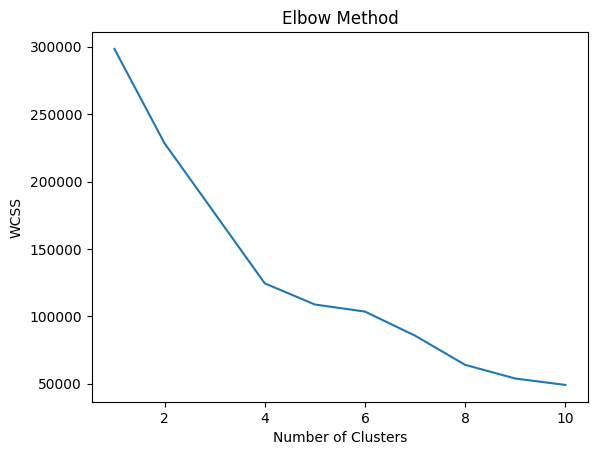

In [9]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

wcss = []

for i in range(1, 11):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 11), wcss)
plt.title('Elbow Method')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')

plt.savefig("elbow.png")  # 👉 IMPORTANT (image for GitHub)
plt.show()

In [10]:
kmeans = KMeans(n_clusters=4, random_state=42)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

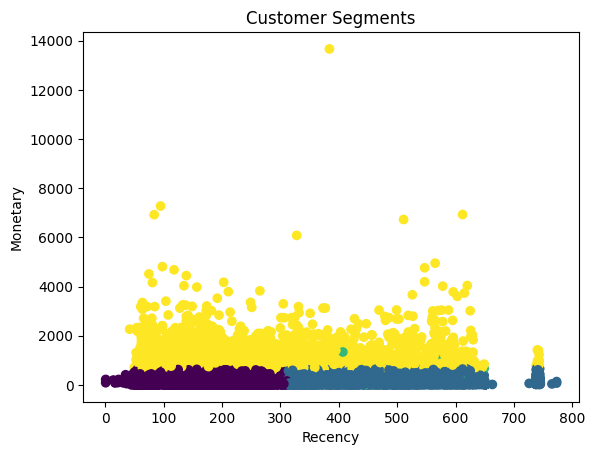

In [11]:
plt.scatter(rfm['Recency'], rfm['Monetary'], c=rfm['Cluster'], cmap='viridis')
plt.xlabel('Recency')
plt.ylabel('Monetary')
plt.title('Customer Segments')

plt.savefig("clusters.png")  # 👉 IMPORTANT
plt.show()

In [12]:
rfm.to_csv("rfm_segments.csv")

In [13]:
import os
print(os.getcwd())

C:\Users\LENOVO
